| Column      | Meaning |
| ----------- | ------- |
| Loan_Status | Target  |


# Step 1: Import Required Libraries

In [19]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Model
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve, 
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

# Step 2: Load Dataset

In [20]:
df = pd.read_csv("GB_loan_approve.csv")

print(df.shape)

df.head()

(289, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,1
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,1
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,1
3,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,1
4,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban,0


# Step 3: Basic Information

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            289 non-null    object 
 1   Gender             289 non-null    object 
 2   Married            289 non-null    object 
 3   Dependents         289 non-null    object 
 4   Education          289 non-null    object 
 5   Self_Employed      289 non-null    object 
 6   ApplicantIncome    289 non-null    int64  
 7   CoapplicantIncome  289 non-null    int64  
 8   LoanAmount         289 non-null    float64
 9   Loan_Amount_Term   289 non-null    float64
 10  Credit_History     289 non-null    float64
 11  Property_Area      289 non-null    object 
 12  Loan_Status        289 non-null    int64  
dtypes: float64(3), int64(3), object(7)
memory usage: 29.5+ KB


In [22]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000
mean,4637.352941,1528.262976,136.792388,342.671280,0.840830,0.629758
std,4790.683934,2377.599209,59.699582,65.655503,0.366469,0.483707
min,0.000000,0.000000,28.000000,6.000000,0.000000,0.000000
25%,2875.000000,0.000000,102.000000,360.000000,1.000000,0.000000
50%,3833.000000,879.000000,126.000000,360.000000,1.000000,1.000000
75%,5000.000000,2400.000000,158.000000,360.000000,1.000000,1.000000
max,72529.000000,24000.000000,460.000000,480.000000,1.000000,1.000000


# Step 4: Check Missing Values

In [23]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

# Step 5: Handle Missing Values

In [24]:
# Numerical Columns
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace = True)

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace = True)

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace = True)

# Categorical Columns

categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed'
]

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace = True)

# Step 6: Drop Loan_ID

In [25]:
df.drop('Loan_ID', axis=1, inplace=True)

# Step 7: Target Variable Distribution

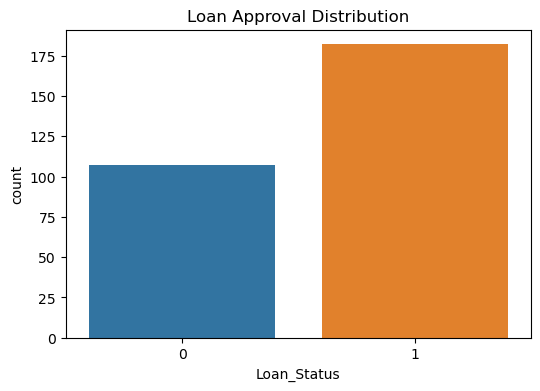

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Distribution")

plt.show()

# Step 8: Loan Approval Percentage

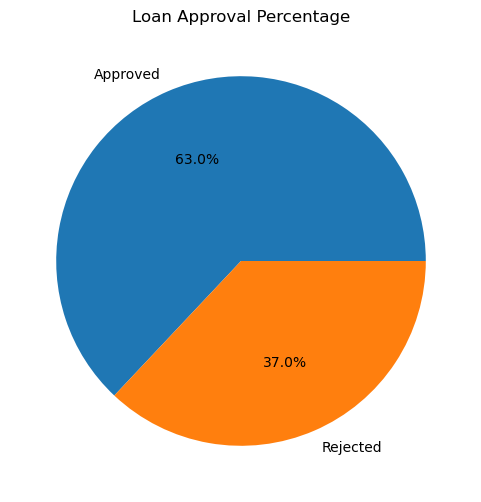

In [27]:
loan_status = df['Loan_Status'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    loan_status,
    labels=['Approved','Rejected'],
    autopct='%1.1f%%'
)

plt.title("Loan Approval Percentage")

plt.show()

# Step 9: Applicant Income Distribution

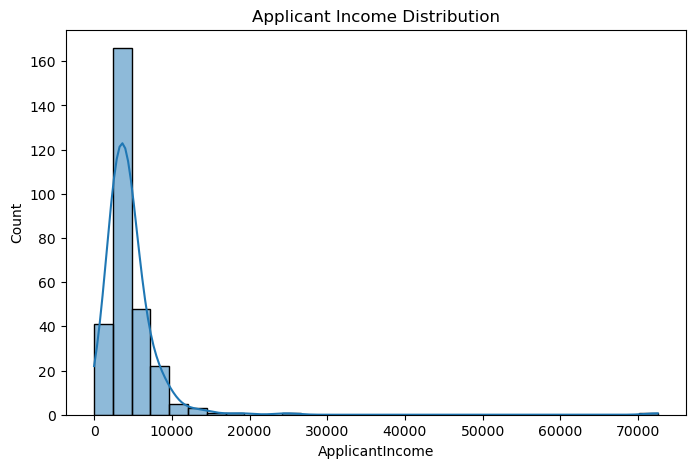

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['ApplicantIncome'],
    bins=30,
    kde=True
)

plt.title("Applicant Income Distribution")

plt.show()

# Step 10: Loan Amount Distribution

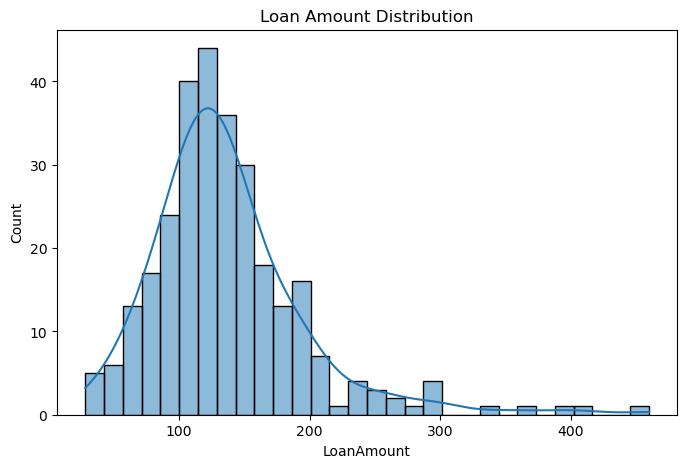

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['LoanAmount'],
    bins=30,
    kde=True
)

plt.title("Loan Amount Distribution")

plt.show()

# Step 11: Credit History vs Loan Status

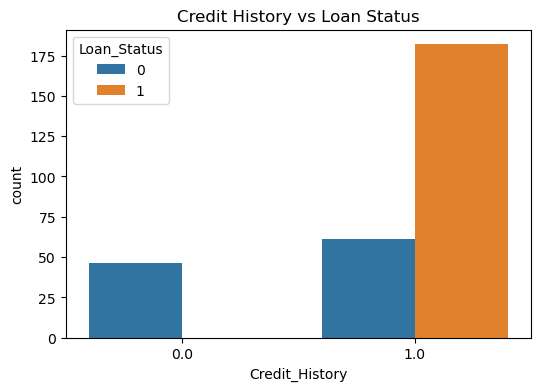

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=df
)

plt.title("Credit History vs Loan Status")

plt.show()

# Step 12: Encode Categorical Variables

In [32]:
df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.columns:
    
    if df_encoded[col].dtype == 'object':
        
        df_encoded[col] = le.fit_transform(
            df_encoded[col]
        )
        
df_encoded

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,1,0,0,0,5720,0,110.0,360.0,1.0,2,1
1,1,1,1,0,0,3076,1500,126.0,360.0,1.0,2,1
2,1,1,2,0,0,5000,1800,208.0,360.0,1.0,2,1
3,1,0,0,1,0,3276,0,78.0,360.0,1.0,2,1
4,1,1,0,1,1,2165,3422,152.0,360.0,1.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
284,1,1,1,0,0,2269,2167,99.0,360.0,1.0,1,0
285,1,1,3,1,1,4009,1777,113.0,360.0,1.0,2,1
286,1,1,0,0,0,4158,709,115.0,360.0,1.0,2,1
287,1,1,0,0,0,5000,2393,158.0,360.0,1.0,0,1


# Step 13: Correlation Heatmap

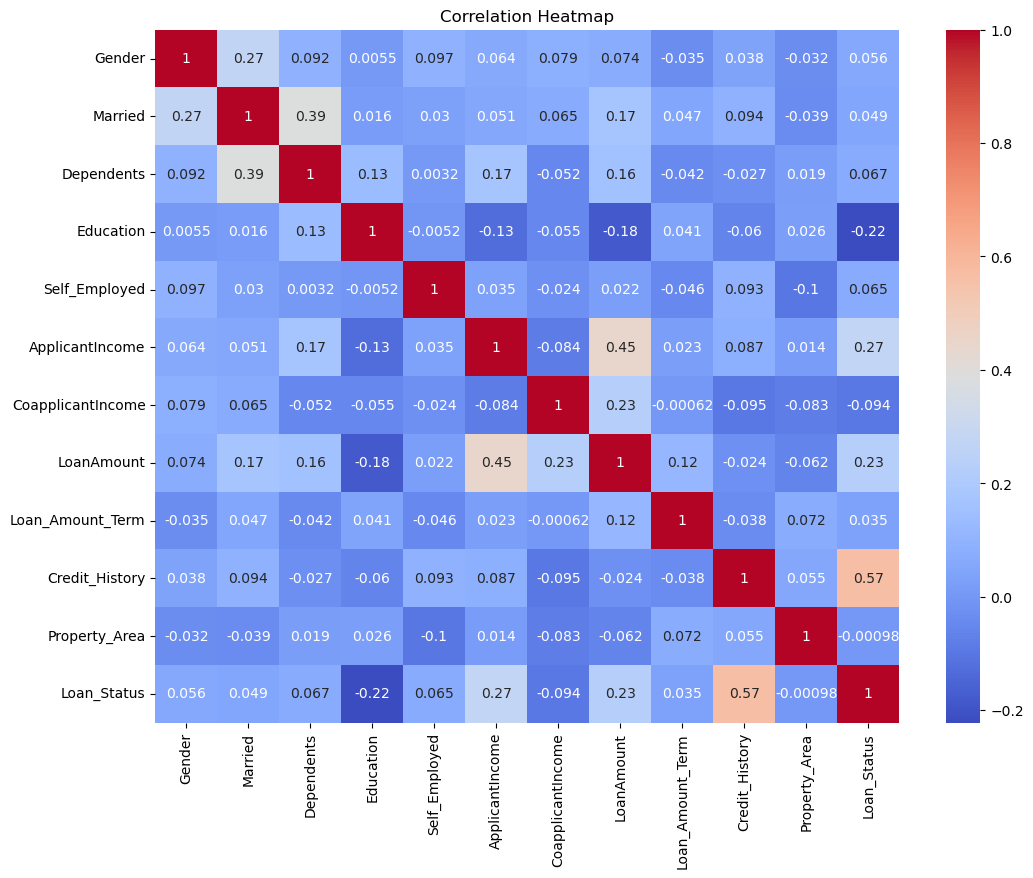

In [34]:
plt.figure(figsize = (12,9))

sns.heatmap(
    df_encoded.corr(),
    annot = True,
    cmap = 'coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Step 14: Define X and y

In [35]:
X = df_encoded.drop(
    'Loan_Status',
    axis = 1
)

y = df_encoded['Loan_Status']

# Step 15: Train Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (231, 11)
Testing Shape : (58, 11)


# Step 16: Build Gradient Boosting Model

In [38]:
gb_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

# Step 17: Prediction

In [39]:
y_pred = gb_model.predict(X_test)

y_prob = gb_model.predict_proba(X_test)[:,1]

# Step 18: Accuracy Score

In [40]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), '%')

Accuracy : 98.28 %


# Step 19: Confusion Matrix

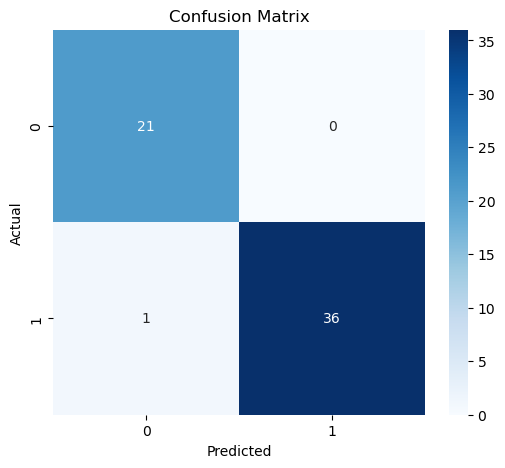

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6,5))

sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Step 20: Classification Report

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.97      0.99        37

    accuracy                           0.98        58
   macro avg       0.98      0.99      0.98        58
weighted avg       0.98      0.98      0.98        58



# Step 21: ROC Curve

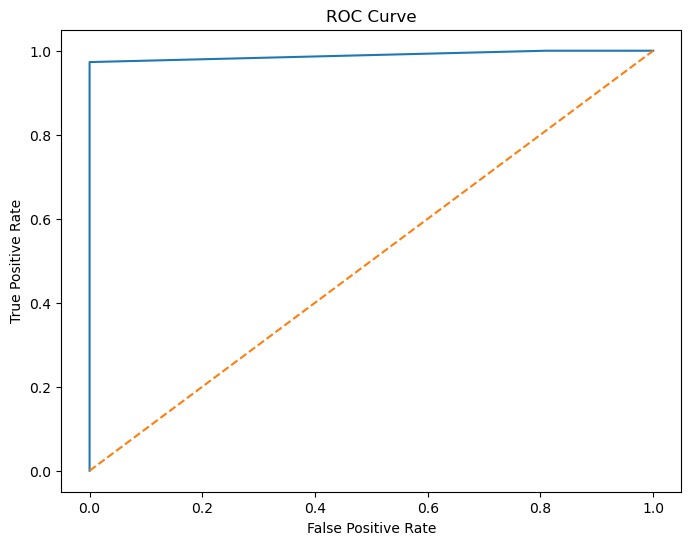

In [43]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize = (8,6))

plt.plot(fpr, tpr, label = f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], '--')

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

# Step 22: AUC Score

In [44]:
print("AUC Score :", round(auc_score, 4))

AUC Score : 0.9891


# Step 23: Feature Importance

In [48]:
importance = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : gb_model.feature_importances_
})

importance = importance.sort_values(
    by = 'Importance',
    ascending = False
)

importance.head(10)

,Feature,Importance
5,ApplicantIncome,6.601989e-01
9,Credit_History,3.398011e-01
6,CoapplicantIncome,2.098320e-16
3,Education,1.638651e-16
0,Gender,0.000000e+00
1,Married,0.000000e+00
2,Dependents,0.000000e+00
4,Self_Employed,0.000000e+00
8,Loan_Amount_Term,0.000000e+00
7,LoanAmount,-1.144363e-17


# Step 24: Feature Importance Graph

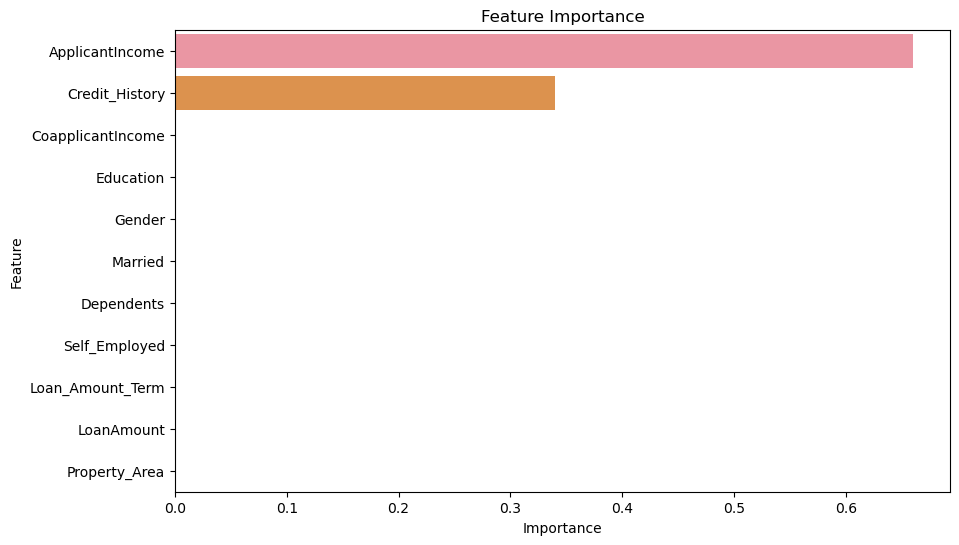

In [49]:
plt.figure(figsize =(10,6))

sns.barplot(x = 'Importance', y = 'Feature', data = importance)

plt.title("Feature Importance")

plt.show()

# Step 25: Training Accuracy

In [50]:
train_pred = gb_model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy :", round(train_acc*100,2), '%')

Training Accuracy : 100.0 %


# Step 26: Testing Accuracy

In [51]:
test_acc = accuracy_score(y_test, y_pred)

print("Testing Accuracy :", round(test_acc*100,2), '%')

Testing Accuracy : 98.28 %


# Step 27: Overfitting Check

In [53]:
difference = train_acc - test_acc

print("Training Accuracy :", round(train_acc*100,2), '%')

print("Testing Accuracy :", round(test_acc*100,2), '%')

print("Difference :", round(difference*100,2), '%')

Training Accuracy : 100.0 %
Testing Accuracy : 98.28 %
Difference : 1.72 %


# Step 28: Actual vs Predicted

In [54]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head(20)

,Actual,Predicted
69,1,1
101,0,0
157,0,0
6,0,0
50,0,0
243,0,0
57,1,1
217,0,0
109,1,1
5,0,0


# Step 29: Loan Approval Probability

In [55]:
probability_df = pd.DataFrame({
    'Actual': y_test,
    'Approval_Probability': y_prob
})

probability_df.head(20)

,Actual,Approval_Probability
69,1,0.999983
101,0,0.000027
157,0,0.000027
6,0,0.000027
50,0,0.000027
243,0,0.000027
57,1,0.999983
217,0,0.000027
109,1,0.999983
5,0,0.000027


# Step 30: Save Model

In [56]:
import joblib

joblib.dump(
    gb_model,
    "GradientBoosting_LoanApproval.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
